# Training ResNet for Audio Spoofing Detection

ResNet model adapted from **Deep Residual Neural Networks for Audio Spoofing Detection** ([paper](https://dx.doi.org/10.21437/Interspeech.2019-3174), [repo](https://github.com/nesl/asvspoof2019/tree/master)). <br>
Training procedure adapted from **Towards Frequency Band Explainability in Synthetic Speech Detection** ([paper](https://dx.doi.org/10.23919/EUSIPCO58844.2023.10289804))

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import random
import numpy as np
import torch
import os

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)

In [4]:
from src.data_utils import ASVDataset, collate_fn_asvspoof
from src.features import log_spectrum_extractor, band_isolator
from src.samplers import BalancedBatchSampler
from src.utils import EarlyStopping
from src.models.resnet import SpectrogramModel
from sklearn.metrics import roc_curve, roc_auc_score, balanced_accuracy_score
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

from IPython.display import Audio, display
from torchinfo import summary
from tqdm.auto import tqdm

import soundfile as sf
import librosa
import pandas as pd
import matplotlib.pyplot as plt

## Loading LA subset + extracting features
- All audio clips are resized to a length of 2 seconds (32,000 samples);
- Log-spectrograms are computed for every audio clip (window size = 2048 with 25% overlap)

In [5]:
DATA_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA')
PROTOCOLS_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA' / 'ASVspoof2019_LA_cm_protocols')
CACHE_DIR = str(Path.cwd().parent / 'data_caches')

band_transform = band_isolator(num_bands=5, isolated_band=0)

FEATURE_NAME = 'spec'

In [6]:
train_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH, 
    is_train=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=3.0, pad_to_max=True, use_vad=True, transform=log_spectrum_extractor, online_transform=band_transform
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name train
protocols_fname train.trn
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_train/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_train_LA_spec_3.0s_pad_vad.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_train_LA_spec_3.0s_pad_vad.npy
Dataset loaded from cache successfully


In [7]:
dev_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH, 
    is_train=False, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=3.0, pad_to_max=True, use_vad=True, transform=log_spectrum_extractor, online_transform=band_transform
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name dev
protocols_fname dev.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_dev/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_spec_3.0s_pad_vad.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_spec_3.0s_pad_vad.npy
Dataset loaded from cache successfully


In [8]:
eval_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH,
    is_eval=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=3.0, pad_to_max=True, use_vad=True, transform=log_spectrum_extractor, online_transform=band_transform
)

sysid_dict_inv {0: '-', 1: 'A07', 2: 'A08', 3: 'A09', 4: 'A10', 5: 'A11', 6: 'A12', 7: 'A13', 8: 'A14', 9: 'A15', 10: 'A16', 11: 'A17', 12: 'A18', 13: 'A19'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name eval
protocols_fname eval.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_eval/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_spec_3.0s_pad_vad.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_spec_3.0s_pad_vad.npy
Dataset loaded from cache successfully


In [9]:
def read_demo_file(path, max_duration):
    audio, sample_rate = sf.read(path, dtype='float32')
    max_samples = int(max_duration * sample_rate)

    from src.vad import trim_silence
    from src.data_utils import pad
    audio = trim_silence(audio)
            
    audio = pad(audio, max_samples, pad_to_max=True)
                
    return audio

In [10]:
demo_indices = [0, 3000, 3000 + 3800 * 2, 3000 + 3800 * 4]
demos = []

for idx, sample_idx in enumerate(demo_indices):
    D, label, meta = train_data[sample_idx]
    audio = read_demo_file(meta.path, 3.0)
    demos.append((audio, D.numpy()[0], label, meta))

In [11]:
for audio, _, label, meta in demos:
    print(f"\n{'Bonafide' if label == 1.0 else 'Spoof'} - {meta.file_name}")
    print(f"System: {train_data.sysid_dict_inv[meta.sys_id]}")
    display(Audio(audio, rate=16000))


Bonafide - LA_T_1138215
System: -



Spoof - LA_T_3740126
System: A01



Spoof - LA_T_3711779
System: A03



Spoof - LA_T_3285771
System: A05


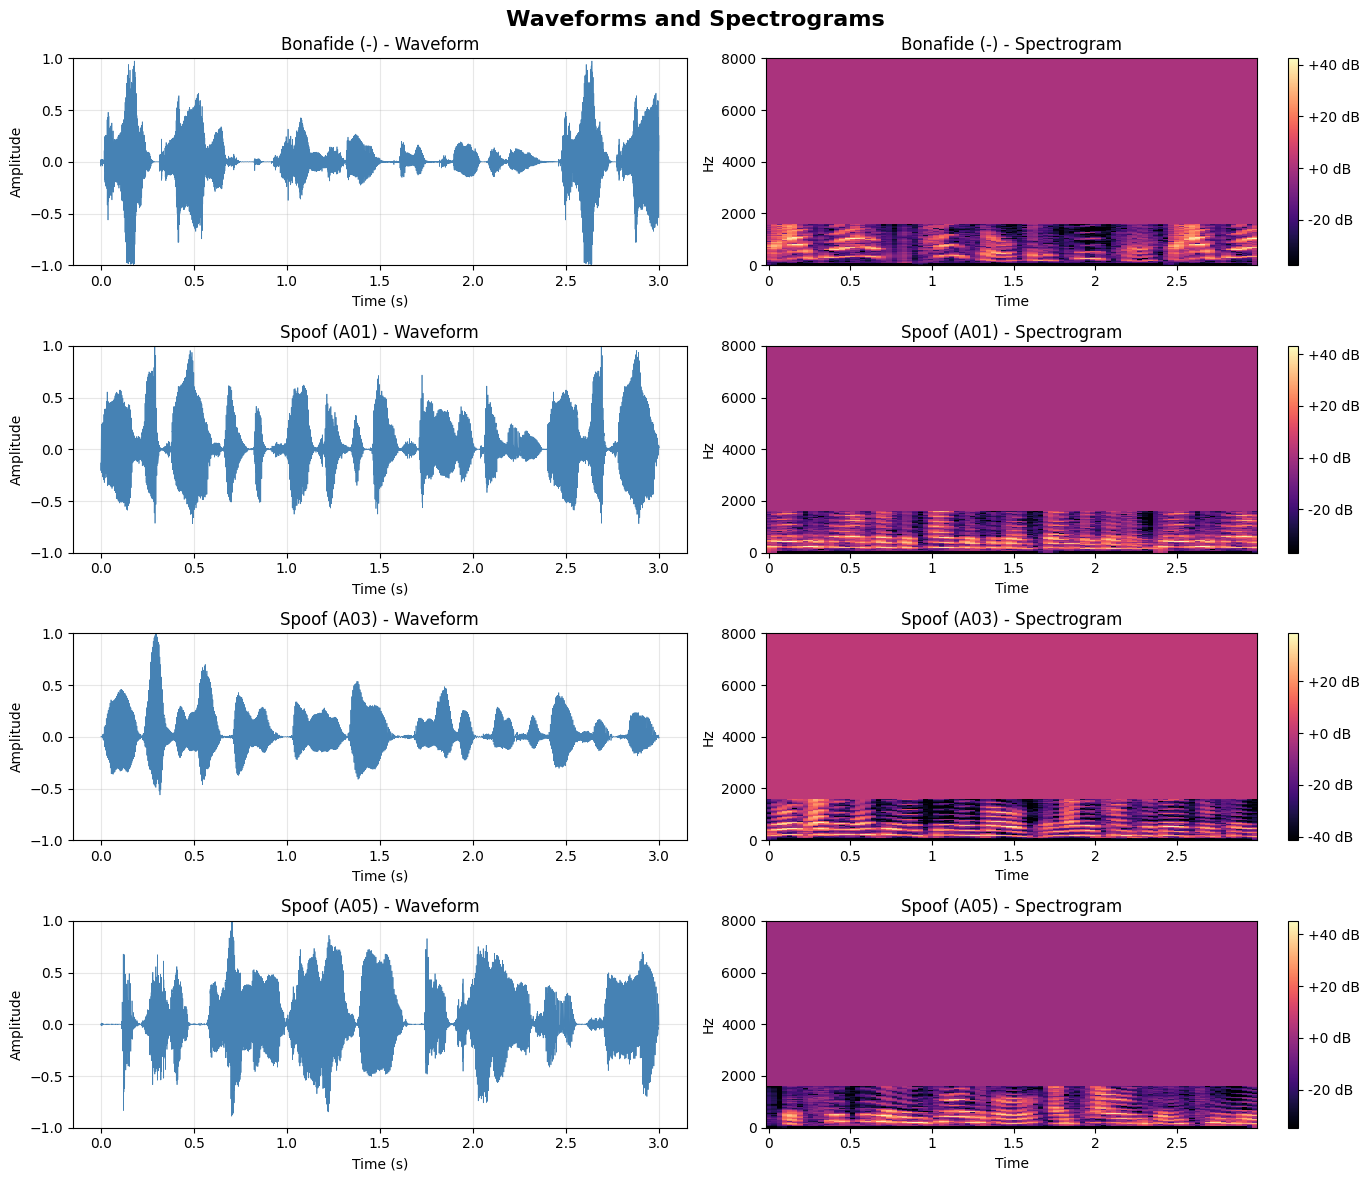

In [12]:
fig, axes = plt.subplots(len(demo_indices), 2, figsize=(14, 3*len(demo_indices)))

for idx, (audio, D, label, meta) in enumerate(demos):
    sys_name = train_data.sysid_dict_inv[meta.sys_id]
    label_name = 'Bonafide' if label == 1.0 else 'Spoof'
    
    # Waveform
    ax_wave = axes[idx, 0]
    time = np.arange(len(audio)) / 16000
    ax_wave.plot(time, audio, linewidth=0.5, color='steelblue')
    ax_wave.set_title(f'{label_name} ({sys_name}) - Waveform')
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_ylim(-1, 1)
    ax_wave.grid(alpha=0.3)
    
    # Spectrogram
    ax_spec = axes[idx, 1]
    img = librosa.display.specshow(D, sr=16000, x_axis='time', y_axis='hz', 
                                    ax=ax_spec, cmap='magma')
    ax_spec.set_title(f'{label_name} ({sys_name}) - Spectrogram')
    plt.colorbar(img, ax=ax_spec, format='%+2.0f dB')

fig.suptitle('Waveforms and Spectrograms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Model

In [13]:
model = SpectrogramModel()

In [14]:
summary(
    model, 
    input_size=(32, 1, 1025, 94),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
SpectrogramModel (SpectrogramModel)      [32, 1, 1025, 94]    [32, 2]              139,360              True
├─Conv2d (conv1)                         [32, 1, 1025, 94]    [32, 32, 1025, 94]   320                  True
├─ResNetBlock (block1)                   [32, 32, 1025, 94]   [32, 32, 342, 32]    --                   True
│    └─Conv2d (conv11)                   [32, 32, 1025, 94]   [32, 32, 342, 32]    9,248                True
│    └─Conv2d (conv1)                    [32, 32, 1025, 94]   [32, 32, 1025, 94]   9,248                True
│    └─BatchNorm2d (bn1)                 [32, 32, 1025, 94]   [32, 32, 1025, 94]   64                   True
│    └─LeakyReLU (lrelu)                 [32, 32, 1025, 94]   [32, 32, 1025, 94]   --                   --
│    └─Dropout (dropout)                 [32, 32, 1025, 94]   [32, 32, 1025, 94]   --                   --
│    └─Conv2d (con

## Training

In [15]:
MODEL_SAVE_DIR = Path.cwd().parent / 'models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
WEIGHTS_FNAME = 'resnet_band_1.pth'
CHECKPOINT_PATH = MODEL_SAVE_DIR / WEIGHTS_FNAME

BATCH_SIZE = 128
NUM_EPOCHS = 100
LEARNING_RATE = 0.00001
PATIENCE = 20

DEVICE = 'cuda:1' if torch.cuda.is_available() else 'cpu'

print(f"Device: {DEVICE}")

Device: cuda:1


In [16]:
train_labels = [int(l) for l in train_data.data_y]
bonafide_count = sum(1 for l in train_labels if l == 1)
spoof_count = len(train_labels) - bonafide_count
print(f"\nTrain class distribution:")
print(f"Bonafide: {bonafide_count} ({bonafide_count/len(train_labels)*100:.1f}%)")
print(f"Spoof: {spoof_count} ({spoof_count/len(train_labels)*100:.1f}%)")

train_sampler = BalancedBatchSampler(
    labels=train_labels,
    batch_size=BATCH_SIZE,
    seed=SEED,
    drop_last=False
)
    
train_loader = DataLoader(
    train_data,
    batch_sampler=train_sampler,
    collate_fn=collate_fn_asvspoof
)

dev_loader = DataLoader(
    dev_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_asvspoof
)

eval_loader = DataLoader(
    eval_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_asvspoof
)

print(f"\nDataLoader batches per epoch:")
print(f"Train: {len(train_loader)}")
print(f"Dev: {len(dev_loader)}")
print(f"Eval: {len(eval_loader)}")


Train class distribution:
Bonafide: 2580 (10.2%)
Spoof: 22800 (89.8%)
BalancedBatchSampler (no majority repeats):
  Bonafide: 2,580
  Spoof:    22,800
  Batch size: 128 (64 per class)
  drop_last: False
  Batches/epoch: 357 (full=356, remainder=16)
  Minority repeats (approx): ~9x
  Last batch will be size 32 (balanced)

DataLoader batches per epoch:
Train: 357
Dev: 195
Eval: 557


In [17]:
model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(), 
    lr=LEARNING_RATE
)
early_stopping = EarlyStopping(patience=PATIENCE, min_delta=0.0, mode="min")

In [18]:
def train_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    if hasattr(loader, 'batch_sampler') and hasattr(loader.batch_sampler, 'set_epoch'):
        loader.batch_sampler.set_epoch(epoch)
    
    pbar = tqdm(loader, desc=f"Epoch {epoch+1} [Train]")
    for batch_idx, (features, labels, _) in enumerate(pbar):
        features = features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({
            'loss': running_loss / (batch_idx + 1),
            'acc': 100. * correct / total
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [19]:
def evaluate(model, loader, criterion, device, partition_name='Dev'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_probs = []
    all_predictions = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc=f"{partition_name}")
        for features, labels, _ in pbar:
            features = features.to(device)
            labels = labels.to(device)
            
            logits = model(features)
            loss = criterion(logits, labels)
            
            probs = torch.nn.functional.softmax(logits, dim=1)[:, 1]
            
            running_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            
            pbar.set_postfix({
                'loss': running_loss / (pbar.n + 1),
                'acc': 100. * correct / total
            })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_predictions = np.array(all_predictions)
    
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=1)
    fnr = 1 - tpr
    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
    
    auc = roc_auc_score(all_labels, all_probs)
    
    balanced_acc = balanced_accuracy_score(all_labels, all_predictions) * 100
    
    return epoch_loss, epoch_acc, eer, auc, balanced_acc, all_labels, all_probs

In [20]:
history = {
    'train_loss': [],
    'train_acc': [],
    'dev_loss': [],
    'dev_acc': [],
    'dev_eer': [],
    'dev_auc': [],
    'dev_balanced_acc': [],
    'lr': []
}

best_eer = float('inf')
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE, epoch
    )
    
    dev_loss, dev_acc, dev_eer, dev_auc, dev_balanced_acc, _, _ = evaluate(
        model, dev_loader, criterion, DEVICE, partition_name='Dev'
    )
    
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['dev_loss'].append(dev_loss)
    history['dev_acc'].append(dev_acc)
    history['dev_eer'].append(dev_eer)
    history['dev_auc'].append(dev_auc)
    history['dev_balanced_acc'].append(dev_balanced_acc)
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Dev Loss:   {dev_loss:.4f} | Dev Acc:   {dev_acc:.2f}%")
    print(f"Dev EER:    {dev_eer:.4f} | Dev AUC:   {dev_auc:.4f}")
    print(f"Dev Balanced Acc: {dev_balanced_acc:.2f}%")
    print(f"LR: {current_lr:.6f}")
    
    if dev_eer < best_eer:
        best_eer = dev_eer
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'dev_eer': dev_eer,
            'dev_loss': dev_loss,
            'dev_auc': dev_auc,
            'dev_balanced_acc': dev_balanced_acc,
            'early_stopping': early_stopping.state_dict()
        }, CHECKPOINT_PATH)
        print(f"Saved best model (EER: {dev_eer:.4f})")
    
    if early_stopping(dev_loss, epoch):
        print(f"Early stopping triggered at epoch {epoch+1}")
        print(f"Best epoch: {early_stopping.best_epoch + 1}")
        print(f"Best dev loss: {early_stopping.best_score:.4f}")
        break

print("Training completed")
print(f"Best Dev EER: {best_eer:.4f} at epoch {best_epoch}")

Epoch 1/100


Epoch 1 [Train]:   0%|          | 0/357 [00:00<?, ?it/s]

Dev:   0%|          | 0/195 [00:00<?, ?it/s]

Train Loss: 0.6936 | Train Acc: 52.73%
Dev Loss:   0.6689 | Dev Acc:   61.18%
Dev EER:    0.4082 | Dev AUC:   0.6308
Dev Balanced Acc: 58.68%
LR: 0.000010
Saved best model (EER: 0.4082)
Epoch 2/100


Epoch 2 [Train]:   0%|          | 0/357 [00:00<?, ?it/s]

...

Dev:   0%|          | 0/195 [00:00<?, ?it/s]

Train Loss: 0.1335 | Train Acc: 95.24%
Dev Loss:   0.2933 | Dev Acc:   90.50%
Dev EER:    0.1854 | Dev AUC:   0.9016
Dev Balanced Acc: 76.61%
LR: 0.000010
Saved best model (EER: 0.1854)
Epoch 55/100


Epoch 55 [Train]:   0%|          | 0/357 [00:00<?, ?it/s]

Dev:   0%|          | 0/195 [00:00<?, ?it/s]

Train Loss: 0.1314 | Train Acc: 95.31%
Dev Loss:   0.2940 | Dev Acc:   90.11%
Dev EER:    0.1824 | Dev AUC:   0.9037
Dev Balanced Acc: 78.10%
LR: 0.000010
Saved best model (EER: 0.1824)
Early stopping triggered at epoch 55
Best epoch: 35
Best dev loss: 0.2738
Training completed
Best Dev EER: 0.1824 at epoch 55


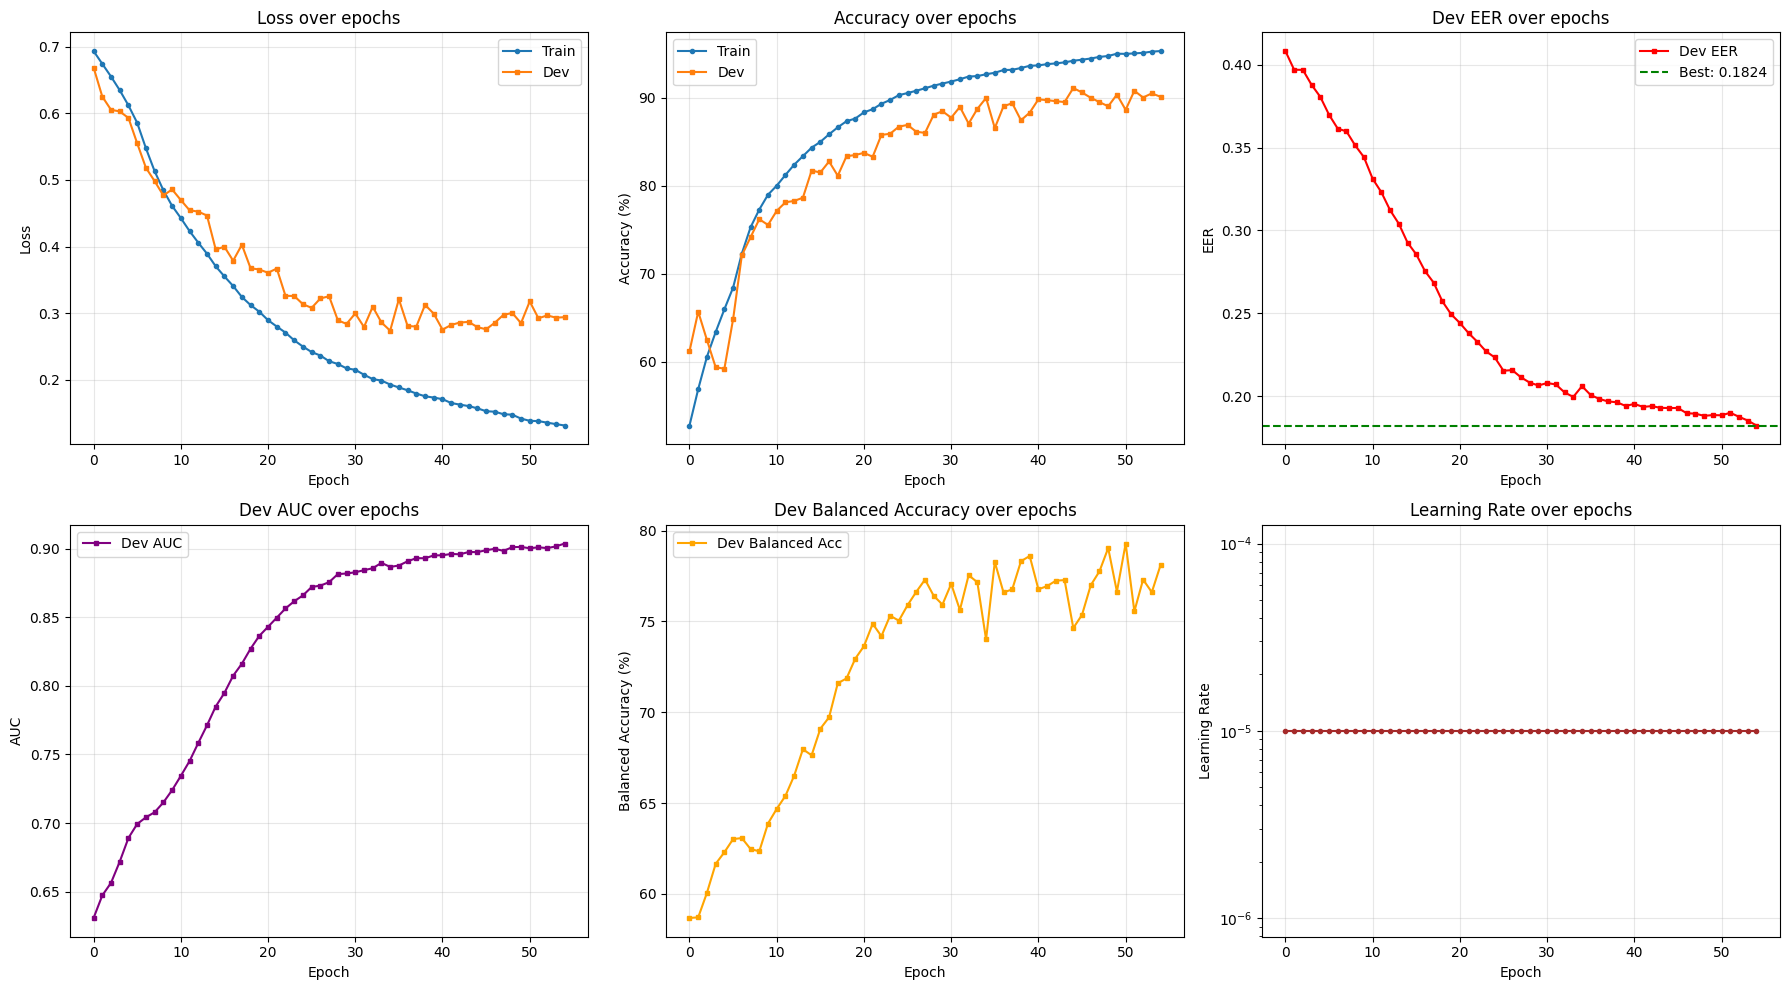

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', marker='o', markersize=3)
axes[0, 0].plot(history['dev_loss'], label='Dev', marker='s', markersize=3)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss over epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train', marker='o', markersize=3)
axes[0, 1].plot(history['dev_acc'], label='Dev', marker='s', markersize=3)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy over epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# EER
axes[0, 2].plot(history['dev_eer'], label='Dev EER', marker='s', markersize=3, color='red')
axes[0, 2].axhline(y=best_eer, color='green', linestyle='--', label=f'Best: {best_eer:.4f}')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('EER')
axes[0, 2].set_title('Dev EER over epochs')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(history['dev_auc'], label='Dev AUC', marker='s', markersize=3, color='purple')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].set_title('Dev AUC over epochs')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Balanced Accuracy
axes[1, 1].plot(history['dev_balanced_acc'], label='Dev Balanced Acc', marker='s', markersize=3, color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Balanced Accuracy (%)')
axes[1, 1].set_title('Dev Balanced Accuracy over epochs')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 2].plot(history['lr'], marker='o', markersize=3, color='brown')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Learning Rate')
axes[1, 2].set_title('Learning Rate over epochs')
axes[1, 2].set_yscale('log')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_hist_band1.png', dpi=150)
plt.show()

In [22]:
import json

with open("history_resnet_band1.json", "w") as f:
    json.dump(history, f, indent=4)

In [23]:
def simple_evaluate(model, data_loader, device, partition_name='Eval'):
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_sys_ids = []
    
    print(f"\nEvaluating {partition_name} set...")
    
    with torch.no_grad():
        for batch_x, batch_y, batch_meta in tqdm(data_loader, desc=partition_name):
            batch_x = batch_x.to(device)
            batch_out = model(batch_x)
            
            _, batch_pred = batch_out.max(dim=1)
            
            all_predictions.extend(batch_pred.cpu().numpy())
            all_labels.extend(batch_y.numpy())

            for meta in batch_meta:
                all_sys_ids.append(meta.sys_id)
    
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_sys_ids = np.array(all_sys_ids)
    
    overall_acc = (all_predictions == all_labels).mean() * 100
    
    print(f"\n{partition_name} Overall Accuracy: {overall_acc:.2f}%")
    
    unique_sys_ids = np.unique(all_sys_ids)
    
    results = []
    
    for sys_id in unique_sys_ids:
        mask = all_sys_ids == sys_id
        
        labels_subset = all_labels[mask]
        preds_subset = all_predictions[mask]
        
        true_label = labels_subset[0]
        
        correct = (preds_subset == labels_subset).sum()
        total = len(labels_subset)
        detection_rate = correct / total
        
        if true_label == 1:
            attack_name = 'REAL'
        else:
            attack_name = data_loader.dataset.sysid_dict_inv[sys_id]
        
        results.append({
            'Attack': attack_name,
            'sys_id': sys_id,
            'Label': 'bonafide' if true_label == 1 else 'spoof',
            'Total': total,
            'Correct': correct,
            'Detection Rate': detection_rate,
        })
    
    df = pd.DataFrame(results)
    
    df['sort_key'] = df['Attack'].apply(lambda x: '0' if x == 'REAL' else x)
    df = df.sort_values('sort_key').drop('sort_key', axis=1)
    df = df.reset_index(drop=True)
    
    return df, overall_acc

In [24]:
def print_detection_table(df, partition_name='Eval'):
    print(f"{partition_name} SET - PER-ATTACK DETECTION RATES")
    
    print("\nDetailed Statistics:")
    print(df.to_string(index=False))
    
    
    attacks = df['Attack'].tolist()
    rates = df['Detection Rate'].tolist()
    
    header = " | ".join([f"{att:^6s}" for att in attacks])
    print(header)
    print("-" * len(header))
    
    values = " | ".join([f"{rate:^6.2f}" for rate in rates])
    print(values)
    
    print(f"\n{'='*80}")
    
    attack_df = df[df['Attack'] != 'REAL']
    if len(attack_df) > 0:
        print("\nSummary (attacks only):")
        print(f"  Mean:   {attack_df['Detection Rate'].mean():.4f}")
        print(f"  Median: {attack_df['Detection Rate'].median():.4f}")
        print(f"  Min:    {attack_df['Detection Rate'].min():.4f} ({attack_df.loc[attack_df['Detection Rate'].idxmin(), 'Attack']})")
        print(f"  Max:    {attack_df['Detection Rate'].max():.4f} ({attack_df.loc[attack_df['Detection Rate'].idxmax(), 'Attack']})")
    
    real_df = df[df['Attack'] == 'REAL']
    if len(real_df) > 0:
        print(f"\nBonafide (REAL) Detection: {real_df['Detection Rate'].values[0]:.4f}")

In [25]:
checkpoint = torch.load(CHECKPOINT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1}")

# Evaluate Dev set
df_dev, acc_dev = simple_evaluate(model, dev_loader, DEVICE, 'Dev')
print_detection_table(df_dev, 'Dev')

# Evaluate Eval set
df_eval, acc_eval = simple_evaluate(model, eval_loader, DEVICE, 'Eval')
print_detection_table(df_eval, 'Eval')

# Save results
results_dir = Path('logs_resnet_band1')
results_dir.mkdir(exist_ok=True)

df_dev.to_csv(results_dir / 'dev_per_attack.csv', index=False)
df_eval.to_csv(results_dir / 'eval_per_attack.csv', index=False)

print(f"\nResults saved to:")
print(f"  - {results_dir / 'dev_per_attack.csv'}")
print(f"  - {results_dir / 'eval_per_attack.csv'}")

Loaded model from epoch 55

Evaluating Dev set...


/tmp/ipykernel_34269/681561531.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH)


Dev:   0%|          | 0/195 [00:00<?, ?it/s]


Dev Overall Accuracy: 90.11%
Dev SET - PER-ATTACK DETECTION RATES

Detailed Statistics:
Attack  sys_id    Label  Total  Correct  Detection Rate
  REAL       0 bonafide   2548     1605        0.629906
   A01       1    spoof   3716     3556        0.956943
   A02       2    spoof   3716     3704        0.996771
   A03       3    spoof   3716     3642        0.980086
   A04       4    spoof   3716     2824        0.759957
   A05       5    spoof   3716     3576        0.962325
   A06       6    spoof   3716     3479        0.936222
 REAL  |  A01   |  A02   |  A03   |  A04   |  A05   |  A06  
------------------------------------------------------------
 0.63  |  0.96  |  1.00  |  0.98  |  0.76  |  0.96  |  0.94 


Summary (attacks only):
  Mean:   0.9321
  Median: 0.9596
  Min:    0.7600 (A04)
  Max:    0.9968 (A02)

Bonafide (REAL) Detection: 0.6299

Evaluating Eval set...


Eval:   0%|          | 0/557 [00:00<?, ?it/s]


Eval Overall Accuracy: 70.71%
Eval SET - PER-ATTACK DETECTION RATES

Detailed Statistics:
Attack  sys_id    Label  Total  Correct  Detection Rate
  REAL       0 bonafide   7355     5462        0.742624
   A07       1    spoof   4914     2339        0.475987
   A08       2    spoof   4914     4508        0.917379
   A09       3    spoof   4914     4538        0.923484
   A10       4    spoof   4914     1708        0.347578
   A11       5    spoof   4914     2043        0.415751
   A12       6    spoof   4914     1638        0.333333
   A13       7    spoof   4914     4350        0.885226
   A14       8    spoof   4914     4801        0.977004
   A15       9    spoof   4914     2328        0.473748
   A16      10    spoof   4914     3640        0.740741
   A17      11    spoof   4914     4504        0.916565
   A18      12    spoof   4914     4320        0.879121
   A19      13    spoof   4914     4196        0.853887
 REAL  |  A07   |  A08   |  A09   |  A10   |  A11   |  A12   |  A13  